# 12장 - LangGraph 도구 에이전트

원본 파일: `chap12/langgraph_tools_agent.py`

In [11]:
import json
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import AIMessageChunk, ToolMessage, SystemMessage, HumanMessage
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from dotenv import load_dotenv
import os

load_dotenv()

model = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv('OPENAI_API_KEY'),
    temperature=0.01,
)

In [12]:
class State(TypedDict):
    messages: Annotated[list[str], add_messages]

In [13]:
graph_builder = StateGraph(State)

In [14]:
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        return f'{timezone} ({location}) 현재시각 {now}'
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"

In [15]:
@tool
def get_web_search(query: str, search_period: str = 'm') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(time=search_period)
    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator=';\n',
    )

    # ddgs 라이브러리가 LibreSSL 환경에서 간헐적으로 TLS 버전 오류를 내므로 재시도
    last_error = None
    for _ in range(3):
        try:
            return search.invoke(query)
        except ValueError as e:
            last_error = e
    return f"검색 중 오류가 발생했습니다: {last_error}"

In [16]:
tools = [get_current_time, get_web_search]
model_with_tools = model.bind_tools(tools)

In [17]:
def generate(state: State):
    """주어진 상태를 기반으로 챗봇의 응답 메시지를 생성"""
    return {"messages": model_with_tools.invoke(state["messages"])}

In [18]:
graph_builder.add_node("generate", generate)

In [19]:
class BasicToolNode:
    """도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")

        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(tool_call["args"])
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result, ensure_ascii=False),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

In [20]:
tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [21]:
def route_tools(state: State):
    """마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고, 그렇지 않은 경우 끝으로 라우팅"""
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [22]:
graph_builder.add_edge(START, "generate")
graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아감
graph_builder.add_edge("tools", "generate")

graph = graph_builder.compile()

## 그래프 구조 시각화

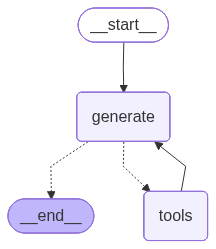

In [23]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 실패 시 통과 (mermaid 렌더링 서버 접속 불가 등)
    pass

## 실행 / 테스트

In [24]:
print("===== 1. 시간 조회 테스트 =====")
inputs = [HumanMessage(content="지금 서울 몇시야?")]
gathered = None
for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')
        gathered = msg if gathered is None else gathered + msg
print()

===== 1. 시간 조회 테스트 =====
현재 서울의 시각은 2026년 7월 3일 17시 28분 29초입니다.


In [25]:
print("\n===== 2. 웹 검색 기반 기사 작성 테스트 =====")
about = "서울월드컵 경기장 잔디 문제"
inputs = [SystemMessage(content=f"""
너는 신문기자이다.
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘.
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐.
- 검색할 리스트를 토대로 재검색을 한다.
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다.

더 이상 검색할 내용이 없다면, 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다.
""")]


===== 2. 웹 검색 기반 기사 작성 테스트 =====


In [26]:
for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')
print()

최근 서울월드컵 경기장 잔디 문제에 대한 이슈가 여러 매체에서 보도되고 있습니다. 특히, WK리그 경기에서 잔디 상태가 좋지 않아 경기가 연기되거나 선수들이 부상을 입는 사례가 발생하고 있어 많은 관심을 받고 있습니다. 이 문제는 단순히 경기장 관리의 문제를 넘어, 선수들의 안전과 경기의 질에 직접적인 영향을 미치기 때문에 선정했습니다.

### 목차
1. 서론
   - 서울월드컵 경기장 잔디 문제의 배경
2. 잔디 상태의 현황
   - 최근 WK리그 경기에서의 잔디 문제 사례
3. 잔디 관리의 중요성
   - 선수 안전과 경기 질에 미치는 영향
4. 해결 방안
   - 잔디 관리 개선을 위한 제안
5. 결론
   - 향후 전망과 필요성

### 추가 검색할 내용 리스트
1. 서울월드컵 경기장 잔디 관리 현황
2. WK리그 경기에서의 잔디 문제 사례
3. 잔디 관리의 중요성에 대한 전문가 의견
4. 다른 국가의 경기장 잔디 관리 사례
5. 잔디 관리 개선을 위한 기술적 접근

이제 추가 검색을 진행하겠습니다.추가 검색 결과를 바탕으로 각 목차 항목에 필요한 정보를 정리하겠습니다.

### 1. 서론
- 서울월드컵 경기장 잔디 문제의 배경
  - 서울월드컵 경기장에서의 잔디 관리 문제는 최근 WK리그 경기에서 잔디 상태가 좋지 않아 경기가 연기되거나 선수들이 부상을 입는 사례가 발생하고 있다는 점에서 중요하다.

### 2. 잔디 상태의 현황
- 최근 WK리그 경기에서의 잔디 문제 사례
  - WK리그 경기에서 잔디 상태가 좋지 않아 경기가 연기되거나 선수들이 부상을 입는 사례가 발생하고 있다는 보도가 있다.
  - 잔디 관리 주체가 부족하고, 관리 인력이 적어 문제가 심각하다는 의견이 있다.

### 3. 잔디 관리의 중요성
- 선수 안전과 경기 질에 미치는 영향
  - 한국프로축구선수협회는 "전문가 없는 잔디 관리가 K리그의 발목을 잡는다"며 잔디 관리 전문 인력 양성과 예산 확대를 주장하고 있다.
  - 잔디 관리가 제대로 이루어지지 않으면 선수들의 부상 